Image Classification using Transfer Learning: Deteksi Jenis Sampah di Sekitar Kampus
Dataset: https://www.kaggle.com/datasets/farzadnekouei/trash-type-image-dataset

In [1]:
%pip install tensorflow matplotlib numpy scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications, callbacks
import matplotlib.pyplot as plt

In [3]:
import tensorflow as tf

print(tf.__version__)
print(tf.keras.__version__)

2.21.0
3.15.0


1. Persiapan Dataset

In [4]:
data_dir = './TrashType_Image_Dataset' 
batch_size = 32
img_size = (224, 224)

In [5]:
# Menggunakan image_dataset_from_directory (Lebih modern & efisien dari ImageDataGenerator)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

# Simpan nama kelas
class_names = train_dataset.class_names

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(AUTOTUNE)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [6]:
print(class_names)


['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


2. Data Augmentation

In [8]:
# Menerapkan augmentasi secara acak HANYA saat training menggunakan Keras Layers
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip('horizontal'),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
])

3. Transfer Learning

In [9]:
# Menggunakan ResNet50 (Sesuai materi: Popular Pre-trained Models)
# Kita gunakan teknik Fixed Feature Extractor (Freeze base model)
base_model = applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze layer agar bobot pre-trained tidak rusak

4. Arsitektur Model

In [10]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs) # Terapkan augmentasi

# Preprocessing input khusus untuk ResNet50
x = applications.resnet50.preprocess_input(x)

# Lewatkan ke base model (training=False agar batch normalization tetap dalam mode inference)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

# Handling Overfitting #3: Dropout Layer
x = layers.Dropout(0.5)(x) 

# Output layer untuk 6 kelas sampah
num_classes = 6
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Learning rate kecil untuk stabilitas
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("--- Model Summary ---")
model.summary()

--- Model Summary ---


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 6)         │     12,294 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 12,294 (48.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

5. Training Model

In [12]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nIsi folder:")
for item in os.listdir():
    print(item)

Current Folder:
c:\Users\ASUS\OneDrive\Semester 6\Machine Learning\Maching Learning Practic 13

Isi folder:
image classification.ipynb
TrashType_Image_Dataset


In [13]:
for images, labels in train_dataset.take(1):
    print("Image :", images.shape)
    print("Label :", labels.shape)
    print(labels[:5])

Image : (32, 224, 224, 3)
Label : (32, 6)
tf.Tensor(
[[0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]], shape=(5, 6), dtype=float32)


In [14]:
# Handling Overfitting #4: Early Stopping
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5,             # Stop jika val_loss tidak membaik selama 5 epoch
    restore_best_weights=True, # Kembalikan bobot epoch terbaik
    verbose=1
)

epochs = 20
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs,
    callbacks=[early_stop]
)

Epoch 1/20


c:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


64/64 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.2804 - loss: 2.1502 - val_accuracy: 0.4495 - val_loss: 1.4726
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.4159 - loss: 1.6204 - val_accuracy: 0.5980 - val_loss: 1.1281
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.4891 - loss: 1.4354 - val_accuracy: 0.6733 - val_loss: 0.9403
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.5514 - loss: 1.2562 - val_accuracy: 0.7069 - val_loss: 0.8236
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.6024 - loss: 1.0745 - val_accuracy: 0.7584 - val_loss: 0.7495
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.6390 - loss: 0.9915 - val_accuracy: 0.7822 - val_loss: 0.6873
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.6503 - loss: 0.9631 - val_accuracy: 0.7980 - val_loss: 0.6500
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.6741 - loss: 0.8962 - val_accuracy: 0.8040 - val_loss: 0.6157
Epo

6. Evaluasi & Cek Overfitting

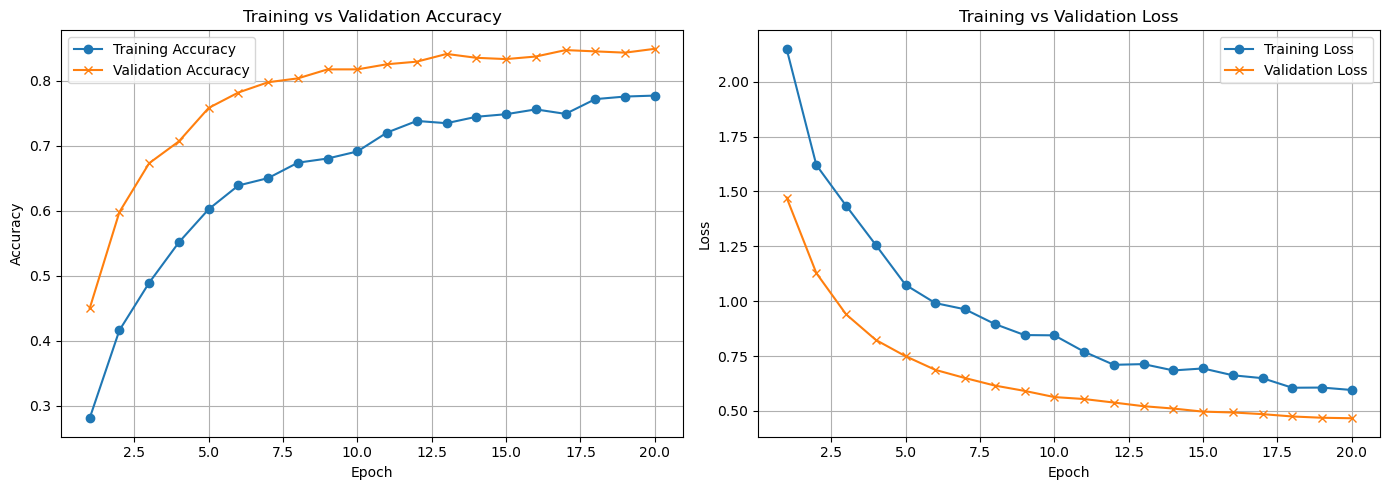

In [16]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14,5))

# Grafik Akurasi
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, 'o-', label='Training Accuracy')
plt.plot(epochs_range, val_acc, 'x-', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Grafik Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, 'o-', label='Training Loss')
plt.plot(epochs_range, val_loss, 'x-', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Kesimpulan**

1. Akurasi validasi 78,73% sedikit lebih tinggi dari akurasi pelatihan (74,56%), yang menunjukkan bahwa model tidak "menghafal" data pelatihan, tetapi mampu melakukan generalisasi yang baik ke data baru.

2. Konvergensi Model Stabil: Nilai val_loss turun secara konsisten dari 1.5208 menjadi 0.6064 tanpa perubahan. Ini menunjukkan bahwa pelatihan berjalan dengan baik.

Dengan menggunakan teknik transfer pembelajaran yang tepat, model dapat mengenali enam jenis sampah dengan baik tanpa mengalami overfitting. Kunci keberhasilan dari kombinasi tiga teknik ini adalah sebagai berikut:
- Data Augmentation (rotasi, flip, zoom) menghasilkan peningkatan variasi data pelatihan
- Dropout(0.5) mencegah neuron saling bergantung (co-adaptation)
- Learning Rate kecil (0.0001) memastikan pembaruan bobot berjalan stabil tanpa merusak fitur VGG16